### Data Cleaning and EDA
---


In [35]:
# importing the required libraries  
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
# reading the dataset
df = pd.read_csv('..\\datasets\\Social_Network_Ads.xls')
print(df.head())

    User Id  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


#### Statistical summary of the dataset:
---

In [37]:
print("Description of the dataset (numeric):")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df.describe())


Description of the dataset (numeric):
            User Id    Age  EstimatedSalary  Purchased
count        400.00 400.00           400.00     400.00
mean  15,691,539.76  37.66        69,742.50       0.36
std       71,658.32  10.48        34,096.96       0.48
min   15,566,689.00  18.00        15,000.00       0.00
25%   15,626,763.75  29.75        43,000.00       0.00
50%   15,694,341.50  37.00        70,000.00       0.00
75%   15,750,363.00  46.00        88,000.00       1.00
max   15,815,236.00  60.00       150,000.00       1.00


In [38]:
print("\nDescription of the dataset (categorical):")
print(df.describe(include='str'))



Description of the dataset (categorical):
        Gender
count      400
unique       2
top     Female
freq       204


In [39]:
print("\nDataset information:")
print(df.info())



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User Id          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB
None


In [40]:
print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Number of missing values in each column:
User Id            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [41]:
# checking the duplicates rows
print(df.duplicated().sum())

0


---

In [42]:
df.columns = (df.columns
              .str.strip()
              .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
              .str.replace(' ', '_')
              .str.lower()
              )


In [43]:
# converting the str values of column gender to binary values 
df['gender'] = df['gender'].replace({'Female': 1, 'Male': 0})

In [44]:
df.head()

,user__id,gender,age,estimated_salary,purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [45]:
df.tail()

,user__id,gender,age,estimated_salary,purchased
395,15691863,1,46,41000,1
396,15706071,0,51,23000,1
397,15654296,1,50,20000,1
398,15755018,0,36,33000,0
399,15594041,1,49,36000,1


In [46]:
# saving the cleaned csv into new csv file
df.to_csv('..\\datasets\\cust_data_cleaned.csv', index= False)

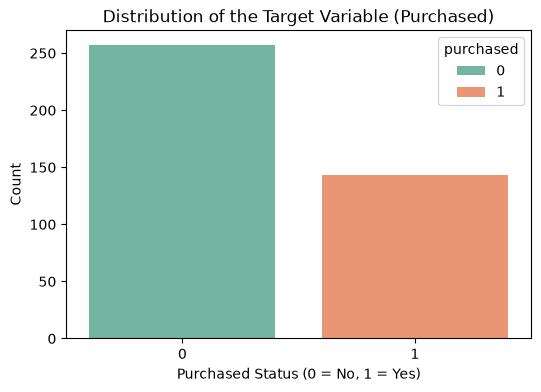

In [47]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='purchased', hue='purchased', data=df, palette='Set2')
plt.title("Distribution of the Target Variable (Purchased)")
plt.xlabel("Purchased Status (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

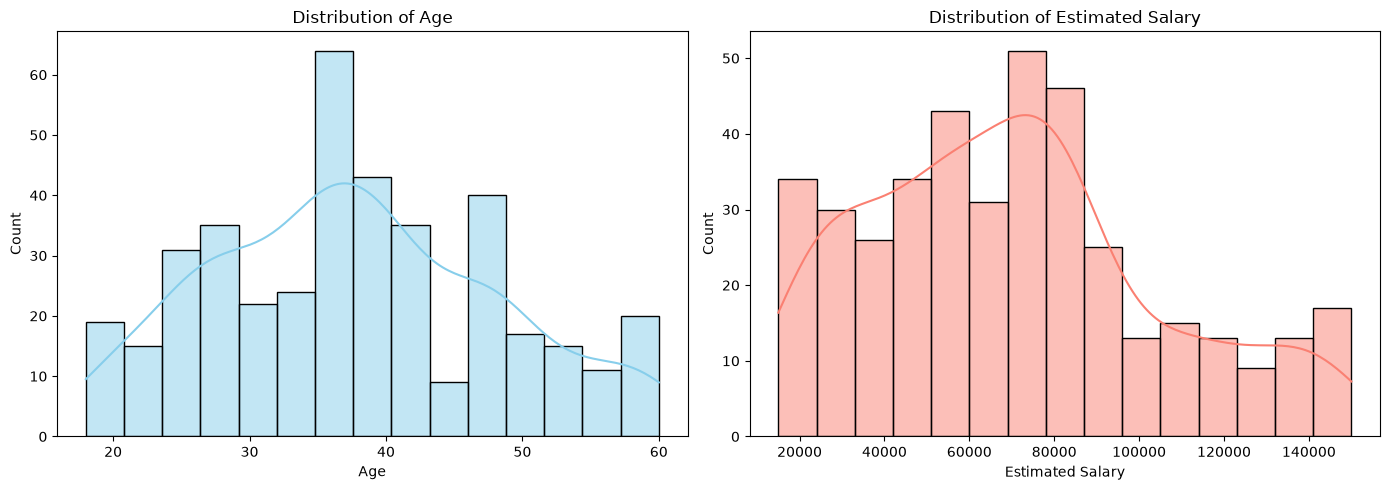

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Age Distribution
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue', bins=15)
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')

# Plot Salary Distribution
sns.histplot(df['estimated_salary'], kde=True, ax=axes[1], color='salmon', bins=15)
axes[1].set_title('Distribution of Estimated Salary')
axes[1].set_xlabel('Estimated Salary')

plt.tight_layout()
plt.show()

In [49]:
print("Feature Skewness: ")
print(df[['age', 'estimated_salary']].skew())

Feature Skewness: 
age                0.23
estimated_salary   0.50
dtype: float64


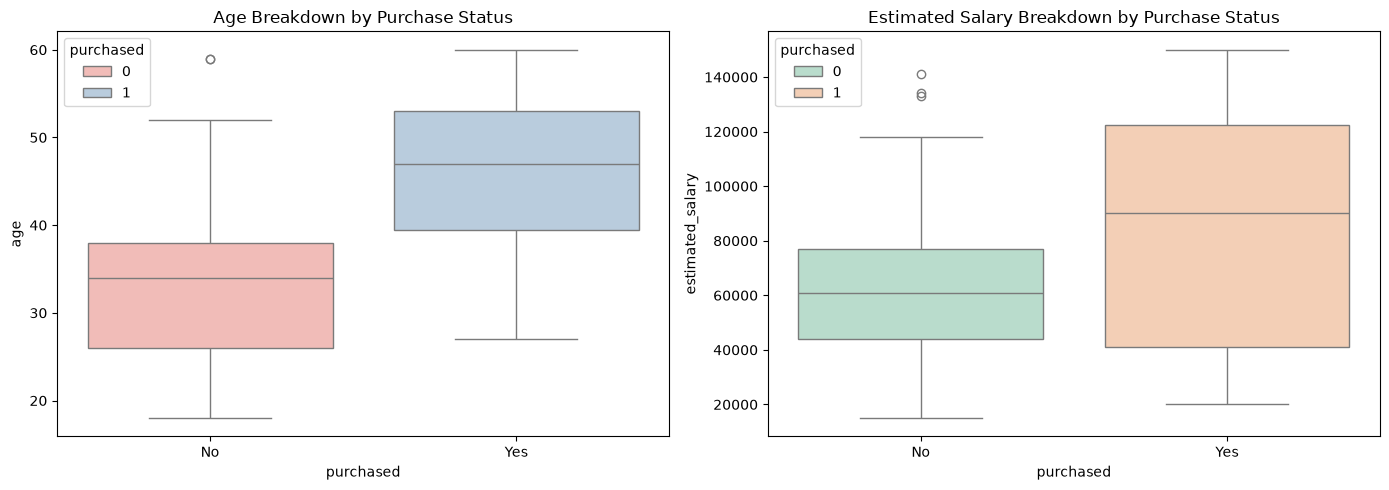

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Purchased
sns.boxplot(x='purchased',hue='purchased', y='age', data=df, ax=axes[0], palette='Pastel1')
axes[0].set_title('Age Breakdown by Purchase Status')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# Salary vs Purchased
sns.boxplot(x='purchased',hue='purchased', y='estimated_salary', data=df, ax=axes[1], palette='Pastel2')
axes[1].set_title('Estimated Salary Breakdown by Purchase Status')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

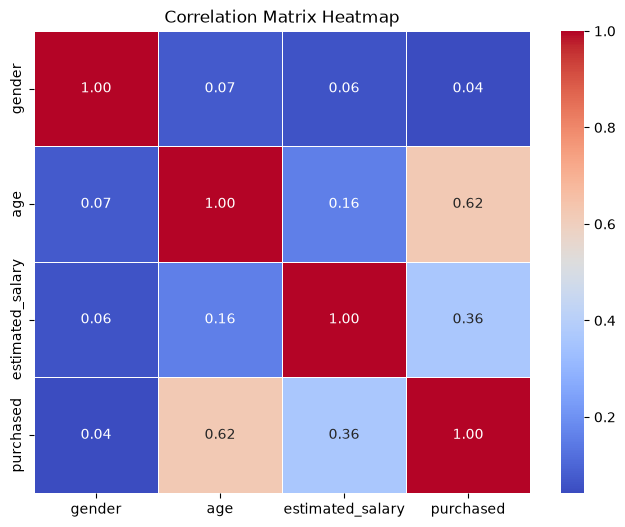

In [51]:
plt.figure(figsize=(8, 6))

# Drop user_id as it is a random identifier sequence
corr_matrix = df.drop(columns=['user__id']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()